In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('marketing_dataset_sample.csv')
df['Week'] = pd.to_datetime(df['Week'])

# Time Arrange 
df = df.sort_values('Week').reset_index(drop=True)

print(" Data loaded")
print(f"Shape: {df.shape}")
print(f"Date range: {df['Week'].min()} to {df['Week'].max()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

 Data loaded
Shape: (60, 15)
Date range: 2024-01-07 00:00:00 to 2025-02-23 00:00:00

First 3 rows:
        Week     FB_Spend     GG_Spend  Seasonality  Promo    FB_Adstock  \
0 2024-01-07  4247.240713  5720.741028     1.000000      1   4247.240713   
1 2024-01-14  7704.285838  4899.443222     1.031813      1   9827.906195   
2 2024-01-21  6391.963651  8801.162564     1.062815      0  11305.916750   

     GG_Adstock  FB_Effect  GG_Effect      Traffic       Sales       Clicks  \
0   5720.741028   0.419132   0.566926  2882.392277  356.442465  2882.392277   
1   6615.665531   0.794387   0.636454  3933.723103  432.305673  3933.723103   
2  10785.862220   0.836413   0.823115  4804.874393  426.433121  4804.874393   

   Conversions       CPC        CR  
0   356.442465  3.683781  0.123662  
1   432.305673  4.896307  0.109897  
2   426.433121  3.325770  0.088750  


In [30]:
# Basic carculation
df['CPC_FB'] = df['FB_Spend'] / (df['Clicks'] / 2)  
df['CPC_GG'] = df['GG_Spend'] / (df['Clicks'] / 2)
df['CPC_Avg'] = df['CPC_FB'] * 0.5 + df['CPC_GG'] * 0.5  

# CPA (Cost Per Acquisition)
df['CPA'] = (df['FB_Spend'] + df['GG_Spend']) / (df['Conversions'] + 1e-6)

# ROAS (Return on Ad Spend)
df['ROAS'] = df['Sales'] / (df['FB_Spend'] + df['GG_Spend'] + 1e-6)

# ROI (Return on Investment)
df['ROI'] = (df['Sales'] - (df['FB_Spend'] + df['GG_Spend'])) / (df['FB_Spend'] + df['GG_Spend'] + 1e-6)

# CR (Conversion Rate) 
df['CR_Calculated'] = df['Conversions'] / (df['Clicks'] + 1e-6)

# CTR (Click Through Rate) 

print(" Calculated marketing metrics")
print(f"\n Summary stats:")
print(f"   CPC Avg: {df['CPC_Avg'].mean():.0f} (min: {df['CPC_Avg'].min():.0f}, max: {df['CPC_Avg'].max():.0f})")
print(f"   CPA: {df['CPA'].mean():.0f} (min: {df['CPA'].min():.0f}, max: {df['CPA'].max():.0f})")
print(f"   ROAS: {df['ROAS'].mean():.2f}x")
print(f"   ROI: {df['ROI'].mean():.2%}")
print(f"   CR: {df['CR_Calculated'].mean():.2%}")

 Calculated marketing metrics

 Summary stats:
   CPC Avg: 3 (min: 2, max: 4)
   CPA: 27 (min: 15, max: 38)
   ROAS: 0.04x
   ROI: -96.14%
   CR: 9.68%


In [31]:
class ThresholdManager:
    
    def __init__(self, df, lookback_weeks=26):
        
        self.lookback = lookback_weeks
        self.thresholds = {}
        self.update_thresholds(df)
    
    def update_thresholds(self, df):
        
        recent = df.tail(self.lookback)
        
        self.thresholds = {
            
            'CPC_high': recent['CPC_Avg'].quantile(0.75),      
            'CPA_high': recent['CPA'].quantile(0.75),          
            
            
            'ROAS_low': recent['ROAS'].quantile(0.25),         
            'ROI_low': recent['ROI'].quantile(0.25),           
            'CR_low': recent['CR_Calculated'].quantile(0.25),  
            
            
            'pct_change_threshold': 0.15,  
        }
        
        print(f" Thresholds updated (based on last {self.lookback} weeks):")
        print(f"   CPC > {self.thresholds['CPC_high']:.0f} → Red Alert")
        print(f"   CPA > {self.thresholds['CPA_high']:.0f} → Red Alert")
        print(f"   ROAS < {self.thresholds['ROAS_low']:.2f} → Red Alert")
        print(f"   ROI < {self.thresholds['ROI_low']:.2%} → Red Alert")
        print(f"   CR < {self.thresholds['CR_low']:.2%} → Red Alert")
    
    def check_metrics(self, row, prev_4weeks_avg):
        alerts = []
        
        # CPC 
        if row['CPC_Avg'] > self.thresholds['CPC_high']:
            pct = (row['CPC_Avg'] / self.thresholds['CPC_high'] - 1) * 100
            alerts.append(f"CPC too high ({row['CPC_Avg']:.0f}đ > threshold {self.thresholds['CPC_high']:.0f}đ, +{pct:.0f}%)")
        
        # CPA 
        if row['CPA'] > self.thresholds['CPA_high']:
            pct = (row['CPA'] / self.thresholds['CPA_high'] - 1) * 100
            alerts.append(f"CPA too high ({row['CPA']:.0f}đ > threshold {self.thresholds['CPA_high']:.0f}đ, +{pct:.0f}%)")
        
        # ROAS 
        if row['ROAS'] < self.thresholds['ROAS_low']:
            pct = (1 - row['ROAS'] / self.thresholds['ROAS_low']) * 100
            alerts.append(f"ROAS too low ({row['ROAS']:.2f}x < threshold {self.thresholds['ROAS_low']:.2f}x, -{pct:.0f}%)")
        
        # ROI 
        if row['ROI'] < self.thresholds['ROI_low']:
            pct = (1 - row['ROI'] / self.thresholds['ROI_low']) * 100
            alerts.append(f"ROI too low ({row['ROI']:.1%} < threshold {self.thresholds['ROI_low']:.1%}, -{pct:.0f}%)")
        
        # CR 
        if row['CR_Calculated'] < self.thresholds['CR_low']:
            pct = (1 - row['CR_Calculated'] / self.thresholds['CR_low']) * 100
            alerts.append(f"CR too low ({row['CR_Calculated']:.2%} < threshold {self.thresholds['CR_low']:.2%}, -{pct:.0f}%)")
        
        for metric in ['CPC_Avg', 'CPA', 'ROAS', 'CR_Calculated']:
            if metric in prev_4weeks_avg:
                current = row[metric]
                prev = prev_4weeks_avg[metric]
                if prev > 0:
                    pct_change = abs((current - prev) / prev)
                    if pct_change > self.thresholds['pct_change_threshold']:
                        direction = "UP" if current > prev else "DOWN"
                        alerts.append(f"{metric} {direction} mutation {pct_change*100:.0f}% compared to four weeks ago")
        
        return alerts

# Activate Threshold
threshold_mgr = ThresholdManager(df, lookback_weeks=26)

print("\n Threshold manager ready")

 Thresholds updated (based on last 26 weeks):
   CPC > 3 → Red Alert
   CPA > 32 → Red Alert
   ROAS < 0.03 → Red Alert
   ROI < -96.88% → Red Alert
   CR < 9.11% → Red Alert

 Threshold manager ready


In [32]:
import joblib
from sklearn.linear_model import Ridge

# Định nghĩa class đầy đủ (có method predict)
class SimpleMarketingModel:
    def __init__(self, model, feature_names):
        self.model = model
        self.coefficients = dict(zip(feature_names, model.coef_))
        self.intercept = model.intercept_
    
    def predict(self, df, spend_cols, promo_col, season_col):
        
        X = df[spend_cols + [promo_col, season_col]].values
        return self.model.predict(X)

# Load model
try:
    model_raw = joblib.load('marketing_model_simple.pkl')
    feature_names = ['FB_Effect', 'GG_Effect', 'Promo', 'Seasonality']
    model = SimpleMarketingModel(model_raw, feature_names)
    print(" Model loaded from file")
except:
    print(" Model not found, training new model...")
    from sklearn.linear_model import Ridge
    X = df[['FB_Effect', 'GG_Effect', 'Promo', 'Seasonality']].values
    y = df['Sales'].values
    model_raw = Ridge(alpha=0.5)
    model_raw.fit(X, y)
    feature_names = ['FB_Effect', 'GG_Effect', 'Promo', 'Seasonality']
    model = SimpleMarketingModel(model_raw, feature_names)
    print(" New model trained")

# Dự báo
df['Sales_Forecast'] = model.predict(df, ['FB_Effect', 'GG_Effect'], 'Promo', 'Seasonality')
df['Sales_Error'] = df['Sales'] - df['Sales_Forecast']
df['Sales_Error_Pct'] = (df['Sales_Error'] / df['Sales']) * 100

print(f"\n Forecast accuracy:")
print(f"   Mean Absolute Error: {df['Sales_Error'].abs().mean():.1f}")
print(f"   Mean Error %: {df['Sales_Error_Pct'].mean():.1f}%")

 Model not found, training new model...
 New model trained

 Forecast accuracy:
   Mean Absolute Error: 18.7
   Mean Error %: -0.5%


In [33]:
def generate_alerts(df, threshold_mgr):
    """Generate alerts for each week"""
    
    alerts_list = []
    
    for i in range(len(df)):
        if i < 4:
            continue
        
        row = df.iloc[i]
        
        # Calculate 4-week rolling average
        prev_4weeks = df.iloc[i-4:i]
        prev_avg = {
            'CPC_Avg': prev_4weeks['CPC_Avg'].mean(),
            'CPA': prev_4weeks['CPA'].mean(),
            'ROAS': prev_4weeks['ROAS'].mean(),
            'CR_Calculated': prev_4weeks['CR_Calculated'].mean(),
        }
        
        # Get alerts from threshold manager
        alerts = threshold_mgr.check_metrics(row, prev_avg)
        
        # Add forecast alerts
        if abs(row['Sales_Error_Pct']) > 15:
            if row['Sales_Error'] < 0:
                alerts.append(f"Sales {abs(row['Sales_Error_Pct']):.0f}% below forecast")
            else:
                alerts.append(f"Sales {row['Sales_Error_Pct']:.0f}% above forecast (good)")
        
        # Action recommendations
        actions = []
        if any('CPC' in a for a in alerts):
            actions.append("Reduce budget or optimize targeting")
        if any('CPA' in a for a in alerts):
            actions.append("Check traffic quality")
        if any('ROAS' in a or 'ROI' in a for a in alerts):
            actions.append("Shift budget to more effective channel")
        if any('CR' in a for a in alerts):
            actions.append("A/B test landing page, check checkout flow")
        if any('Sales' in a and 'below' in a for a in alerts):
            actions.append("Review external factors (competitors, weather, events)")
        
        if not actions:
            actions.append("Continue current campaign")
        
        alerts_list.append({
            'Week': row['Week'],
            'Sales_Actual': row['Sales'],
            'Sales_Forecast': row['Sales_Forecast'],
            'Error_Pct': row['Sales_Error_Pct'],
            'Alerts': '; '.join(alerts) if alerts else 'All metrics within threshold',
            'Actions': ' | '.join(actions)
        })
    
    return pd.DataFrame(alerts_list)

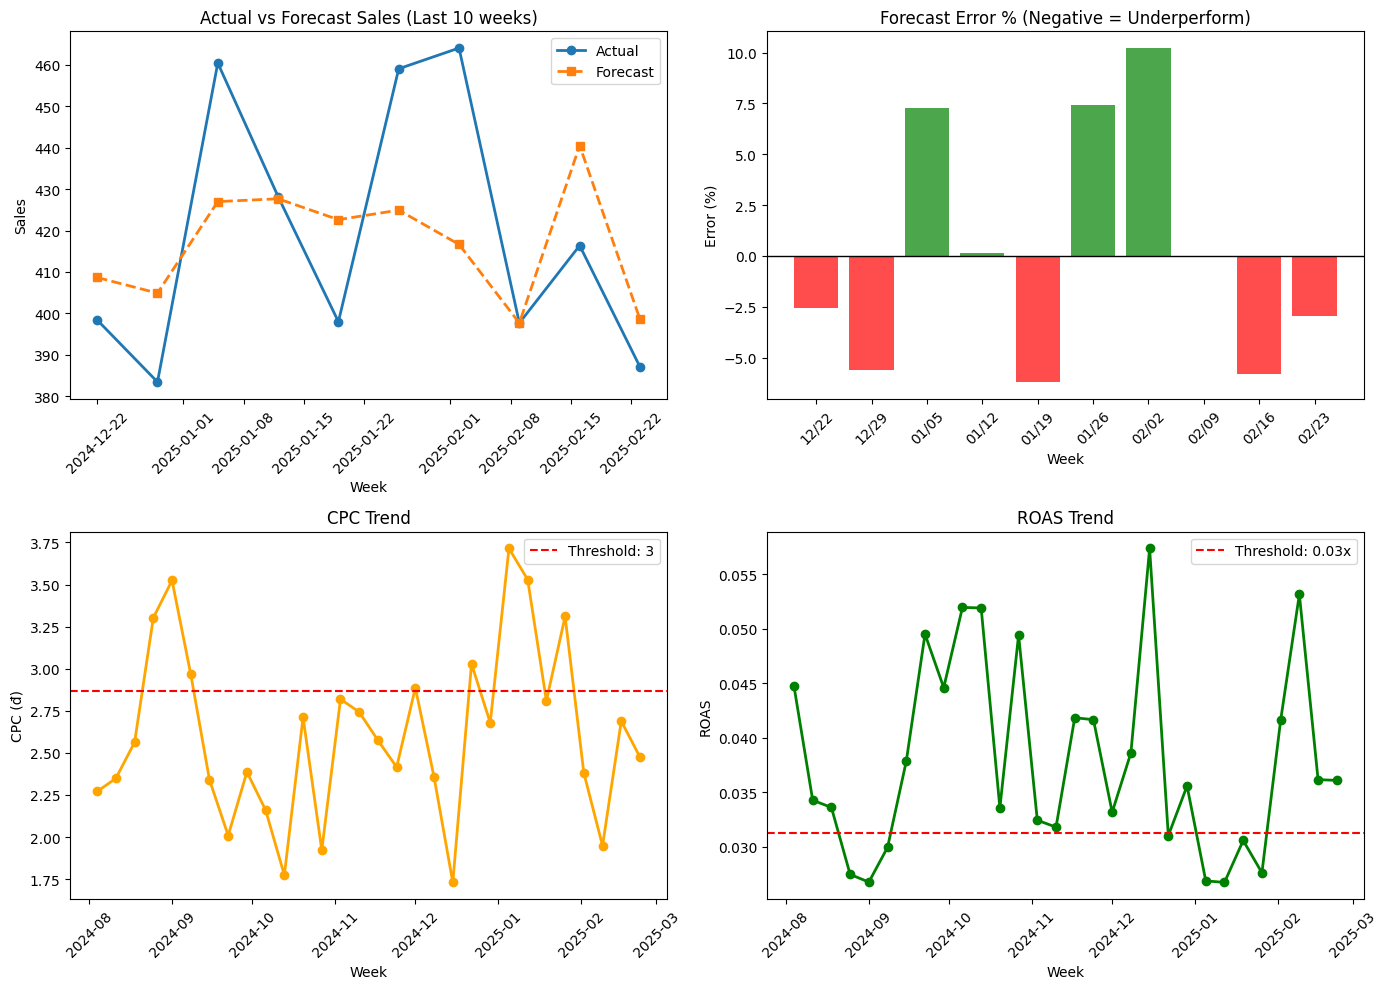

In [34]:

recent_alerts = alerts_df.tail(10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Actual vs Forecast Sales
axes[0,0].plot(recent_alerts['Week'], recent_alerts['Sales_Actual'], 'o-', label='Actual', linewidth=2)
axes[0,0].plot(recent_alerts['Week'], recent_alerts['Sales_Forecast'], 's--', label='Forecast', linewidth=2)
axes[0,0].set_xlabel('Week')
axes[0,0].set_ylabel('Sales')
axes[0,0].set_title('Actual vs Forecast Sales (Last 10 weeks)')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2: Error percentage
colors = ['red' if x < 0 else 'green' for x in recent_alerts['Error_Pct']]
axes[0,1].bar(range(len(recent_alerts)), recent_alerts['Error_Pct'], color=colors, alpha=0.7)
axes[0,1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0,1].set_xlabel('Week')
axes[0,1].set_ylabel('Error (%)')
axes[0,1].set_title('Forecast Error % (Negative = Underperform)')
axes[0,1].set_xticks(range(len(recent_alerts)))
axes[0,1].set_xticklabels([w.strftime('%m/%d') for w in recent_alerts['Week']], rotation=45)

# Chart 3: CPC trend
axes[1,0].plot(df.tail(30)['Week'], df.tail(30)['CPC_Avg'], 'o-', color='orange', linewidth=2)
axes[1,0].axhline(y=threshold_mgr.thresholds['CPC_high'], color='red', linestyle='--', label=f"Threshold: {threshold_mgr.thresholds['CPC_high']:.0f}")
axes[1,0].set_xlabel('Week')
axes[1,0].set_ylabel('CPC (đ)')
axes[1,0].set_title('CPC Trend')
axes[1,0].legend()
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4: ROAS trend
axes[1,1].plot(df.tail(30)['Week'], df.tail(30)['ROAS'], 'o-', color='green', linewidth=2)
axes[1,1].axhline(y=threshold_mgr.thresholds['ROAS_low'], color='red', linestyle='--', label=f"Threshold: {threshold_mgr.thresholds['ROAS_low']:.2f}x")
axes[1,1].set_xlabel('Week')
axes[1,1].set_ylabel('ROAS')
axes[1,1].set_title('ROAS Trend')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [35]:
# Display alert table in English, no icons
print("\n" + "="*100)
print("MARKETING ALERT DASHBOARD")
print("="*100)

for idx, row in alerts_df.tail(10).iterrows():
    print(f"\nWeek: {row['Week'].strftime('%Y-%m-%d')}")
    print(f"   Sales: {row['Sales_Actual']:.0f} (Actual) vs {row['Sales_Forecast']:.0f} (Forecast)")
    
    if row['Error_Pct'] < 0:
        print(f"   Variance: {row['Error_Pct']:.1f}% (Below forecast)")
    else:
        print(f"   Variance: +{row['Error_Pct']:.1f}% (Above forecast)")
    
    # Clean alerts
    alerts_clean = row['Alerts']
    print(f"   Alert: {alerts_clean}")
    print(f"   Action: {row['Actions']}")
    print("-" * 80)

# Save results
alerts_df.to_csv('marketing_alerts.csv', index=False)
print("\nSaved alerts to 'marketing_alerts.csv'")

print("\n" + "="*50)
print("MODULE 4 - COMPLETED")
print("="*50)

# Summary statistics
print("\nSUMMARY STATISTICS:")
print(f"   Total weeks analyzed: {len(alerts_df)}")
print(f"   Weeks with alerts: {(alerts_df['Alerts'] != 'All metrics within threshold').sum()}")
print(f"   Weeks with negative variance: {(alerts_df['Error_Pct'] < 0).sum()}")
print(f"   Weeks with positive variance: {(alerts_df['Error_Pct'] > 0).sum()}")


MARKETING ALERT DASHBOARD

Week: 2024-12-22
   Sales: 398 (Actual) vs 409 (Forecast)
   Variance: -2.6% (Below forecast)
   Alert: CPC too high (3đ > threshold 3đ, +6%); CPA too high (32đ > threshold 32đ, +1%); ROAS too low (0.03x < threshold 0.03x, -1%); ROI too low (-96.9% < threshold -96.9%, --0%); CPC_Avg UP mutation 29% compared to four weeks ago; CPA UP mutation 32% compared to four weeks ago; ROAS DOWN mutation 27% compared to four weeks ago
   Action:  Reduce budget or optimize targeting. |  Check the traffic quality. |  Consider shifting your budget to a more effective channel.
--------------------------------------------------------------------------------

Week: 2024-12-29
   Sales: 383 (Actual) vs 405 (Forecast)
   Variance: -5.6% (Below forecast)
   Alert:  All indicators are within the range.
   Action:  Continue maintaining the current campaign.
--------------------------------------------------------------------------------

Week: 2025-01-05
   Sales: 460 (Actual) vs 4